# CRC mean-shift baseline — whole-domain (TVA) holdout

A **non-learned baseline** for the TVA holdout experiment: instead of training a
model, we take the observed **REF → CRC** mean shift and apply it to the REF
control cells, then evaluate the resulting counterfactual against the held-out
**TVA** cells.

This tells us whether the trained methods (Cellina, SpatialProp, …) actually do
better than *just applying the CRC shift*.

Convention matches `cellina_tva.ipynb` so the numbers slot into the same plots:

- `control` = **all REF cells**
- `target`  = **TVA cells of the holdout cell type** (per holdout CT)
- `delta`   = `log2(mean(CRC) / mean(REF))`  — global, across all cell types
- `cf`      = `(REF + 1) * 2 ** delta - 1`, clipped to ≥0 and renormalised to 1e4

The shift logic mirrors the `baseline` branch of `scripts/eval_loo.py`.

In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
import sys

sys.path.append('../../scripts')

In [3]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

from scipy.stats import pearsonr, spearmanr

DATA_ROOT = os.environ.get("DATA_ROOT", "/data/a330d")

from utils import set_seed
from train_loo import preprocess_crc, split_indices
from counterfactual_analysis import (
    get_baseline_delta,
    get_lfc,
    precision,
    direction_match,
    mixing_index,
    compute_edistance,
    compute_rmse,
    compute_mse_lfc,
    _to_dense,
)
from configs.adata_crc_holdout_config import ADATA_ARGS as ADATA_ARGS_CRC

In [4]:
set_seed(0)

## Config

In [5]:
# This baseline is CRC-specific: it borrows the REF -> CRC shift to predict TVA.
DATASET_NAME = "crc"
SHIFT_DOMAIN = "CRC"          # domain whose REF -> SHIFT shift we transfer to TVA
MODEL_NAME = "baseline-ood"   # label used in the results CSV (mirrors "-ood" suffix)

COUNTS_PER_K = 1e4
n_deg = 50

CRC_PATHS = [
    os.path.join(DATA_ROOT, "datasets/crc/raw_zenodo/crc_120.h5ad"),
    os.path.join(DATA_ROOT, "datasets/crc/raw_zenodo/crc_210.h5ad"),
    os.path.join(DATA_ROOT, "datasets/crc/raw_zenodo/crc_221.h5ad"),
    os.path.join(DATA_ROOT, "datasets/crc/raw_zenodo/crc_231.h5ad"),
    os.path.join(DATA_ROOT, "datasets/crc/raw_zenodo/crc_242.h5ad"),
]

CRC_HOLDOUTS = [
    "Endothelial",
    "Epithelial",
    "Fibroblast",
    "Myeloid",
    "T_cell",
]

PATHS = CRC_PATHS
HOLDOUT_CELLTYPES = CRC_HOLDOUTS
DATA_ARGS = ADATA_ARGS_CRC

In [6]:
n_top_genes = DATA_ARGS.get('n_top_genes')
labels_key = DATA_ARGS.get('labels_key')
domains_key = DATA_ARGS.get('domains_key')
batch_key = DATA_ARGS.get('batch_key')
control_domain = DATA_ARGS.get('control_domains')[0]
holdout_domains = DATA_ARGS.get('holdout_domains')   # ['TVA']

SLIDES = [path.split("/")[-1].split(".h5ad")[0] for path in PATHS]
SLIDES

['crc_120', 'crc_210', 'crc_221', 'crc_231', 'crc_242']

## Compute the baseline counterfactual

For each slide we compute the REF → CRC shift once (it is global, so the
counterfactual is the same for every holdout cell type), then evaluate it
against each held-out cell type in the TVA domain.

In [7]:
def compute_baseline_cf(adata):
    """Apply the global REF -> SHIFT_DOMAIN mean shift to all REF cells.

    Mirrors the `baseline` branch of scripts/eval_loo.py. `delta` is a log2 fold
    change (see get_baseline_delta), so counts are rescaled with `2 ** delta`.
    """
    adata_ref = adata[adata.obs[domains_key] == control_domain]
    adata_shift = adata[adata.obs[domains_key] == SHIFT_DOMAIN]

    # delta = log2(mean(CRC) / mean(REF)), global across all cell types
    delta = get_baseline_delta(adata_ref, adata_shift)

    control = _to_dense(adata_ref.layers['counts'])           # all REF cells (raw counts)
    cf = (control + 1) * (2 ** delta) - 1
    cf = np.clip(cf, a_min=0, a_max=None)
    cf = cf / (cf.sum(axis=1, keepdims=True) + 1e-8) * COUNTS_PER_K
    return control, cf

In [8]:
results = []
hd = holdout_domains[0]   # 'TVA'

for path, slide_id in zip(PATHS, SLIDES):
    print(f"{'='*40} Slide: {slide_id} {'='*40}")

    # 1. Load & preprocess (same as cellina_tva.ipynb)
    adata = sc.read(path)
    adata = preprocess_crc(adata, n_top_genes=n_top_genes,
                           labels_key=labels_key, domains_key=domains_key)

    present = set(adata.obs[domains_key].astype(str).unique())
    if SHIFT_DOMAIN not in present:
        print(f"  Skipping {slide_id}: no '{SHIFT_DOMAIN}' region to compute the shift from.")
        continue
    if hd not in present:
        print(f"  Skipping {slide_id}: no '{hd}' (target) region to evaluate against.")
        continue

    # 2. Split so the whole TVA domain is flagged is_holdout (needed by compute_edistance).
    #    dummy_holdout_ct is unused when holdout_full_domain=True.
    train_idx, val_idx, test_idx = split_indices(
        adata,
        holdout_celltype='Fibroblast',
        labels_key=labels_key,
        domains_key=domains_key,
        holdout_domains=holdout_domains,
        seed=0,
        holdout_full_domain=True,
    )

    # 3. Baseline counterfactual (global REF -> CRC shift, applied once to all REF cells)
    control, counterfactual = compute_baseline_cf(adata)

    is_holdout_domain = adata.obs[domains_key].astype(str) == hd
    for holdout_celltype in HOLDOUT_CELLTYPES:
        is_holdout_ct = adata.obs[labels_key].astype(str) == holdout_celltype
        mask_target = (is_holdout_domain & is_holdout_ct).values
        n_target = int(mask_target.sum())
        if n_target < 2:
            print(f"  {holdout_celltype}: only {n_target} target cell(s) in {hd}, skipping.")
            continue

        target = _to_dense(adata.layers['counts'][mask_target, :])

        # Metrics (identical set/order to cellina_tva.ipynb)
        gt_lfc, cf_lfc, deg = get_lfc(control=control, target=target,
                                      counterfactual=counterfactual, n_deg=n_deg)

        spear, _ = spearmanr(gt_lfc[deg], cf_lfc[deg])
        pear, _ = pearsonr(gt_lfc[deg], cf_lfc[deg])
        prec = precision(gt_lfc, cf_lfc, k=n_deg, use_abs=True)
        dir_match = direction_match(gt_lfc, cf_lfc, k=n_deg, normalize="intersection")
        dir_match_k = direction_match(gt_lfc, cf_lfc, k=n_deg, normalize="k")
        dir_match_gt = direction_match(gt_lfc, cf_lfc, k=n_deg, normalize="gt_topk")
        mix_idx = mixing_index(observed=target, predicted=counterfactual, library_size=COUNTS_PER_K)
        edist_global = compute_edistance(adata, observed=target, predicted=counterfactual, deg=None, library_size=COUNTS_PER_K)
        edist_local = compute_edistance(adata, observed=target, predicted=counterfactual, deg=None, library_size=COUNTS_PER_K, local=True)
        edist_pca_log = compute_edistance(adata, observed=target, predicted=counterfactual, deg=None, library_size=COUNTS_PER_K, local=True, use_pca=True)
        edist_pca = compute_edistance(adata, observed=target, predicted=counterfactual, deg=None, library_size=COUNTS_PER_K, local=True, use_pca=True, log1p=False)
        rmse = compute_rmse(observed=target, predicted=counterfactual, deg=deg, library_size=COUNTS_PER_K)
        mse_lfc = compute_mse_lfc(gt_vec=gt_lfc, cf_vec=cf_lfc, deg=deg)

        print(f"  {holdout_celltype}: pearson={pear:.3f} dir_match_k={dir_match_k:.3f} (n_target={n_target})")

        results.append(dict(
            dataset_name=DATASET_NAME,
            sid=slide_id,
            control_domain=control_domain,
            target_domain=hd,
            n_deg=n_deg,
            model_name=MODEL_NAME,
            holdout_celltype=holdout_celltype,
            spearman=spear,
            pearson=pear,
            precision=prec,
            direction_match=dir_match,
            direction_match_k=dir_match_k,
            direction_match_gt=dir_match_gt,
            mixing_index=mix_idx,
            edistance_global=edist_global,
            edistance_local=edist_local,
            edistance_pca_log=edist_pca_log,
            edistance_pca=edist_pca,
            rmse=rmse,
            mse_lfc=mse_lfc,
        ))

======================================== Slide: crc_120 ========================================


/data/ddimitrov/repos/cellina-reproducibility/notebooks/holdout_domain/../../scripts/train_loo.py:180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[labels_key] = adata.obs[labels_key].astype("category")


  Endothelial: pearson=0.774 dir_match_k=0.240 (n_target=1756)
  Epithelial: pearson=0.754 dir_match_k=0.120 (n_target=74093)
  Fibroblast: pearson=0.501 dir_match_k=0.320 (n_target=5667)
  Myeloid: pearson=0.510 dir_match_k=0.340 (n_target=6131)
  T_cell: pearson=0.606 dir_match_k=0.300 (n_target=12541)
======================================== Slide: crc_210 ========================================


/data/ddimitrov/repos/cellina-reproducibility/notebooks/holdout_domain/../../scripts/train_loo.py:180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[labels_key] = adata.obs[labels_key].astype("category")


  Endothelial: pearson=0.369 dir_match_k=0.280 (n_target=2207)
  Epithelial: pearson=0.634 dir_match_k=0.380 (n_target=150841)
  Fibroblast: pearson=0.574 dir_match_k=0.440 (n_target=4550)
  Myeloid: pearson=0.767 dir_match_k=0.400 (n_target=7904)
  T_cell: pearson=0.679 dir_match_k=0.480 (n_target=5424)
======================================== Slide: crc_221 ========================================


...

  Endothelial: pearson=0.675 dir_match_k=0.300 (n_target=4544)
  Epithelial: pearson=0.578 dir_match_k=0.220 (n_target=140881)
  Fibroblast: pearson=0.823 dir_match_k=0.300 (n_target=9034)
  Myeloid: pearson=0.666 dir_match_k=0.260 (n_target=5084)
  T_cell: pearson=0.733 dir_match_k=0.400 (n_target=10730)
======================================== Slide: crc_231 ========================================


/data/ddimitrov/repos/cellina-reproducibility/notebooks/holdout_domain/../../scripts/train_loo.py:180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[labels_key] = adata.obs[labels_key].astype("category")


  Endothelial: pearson=0.565 dir_match_k=0.240 (n_target=1631)
  Epithelial: pearson=0.801 dir_match_k=0.320 (n_target=87511)
  Fibroblast: pearson=0.628 dir_match_k=0.260 (n_target=11971)
  Myeloid: pearson=0.518 dir_match_k=0.260 (n_target=4582)
  T_cell: pearson=0.123 dir_match_k=0.360 (n_target=4303)
======================================== Slide: crc_242 ========================================


/data/ddimitrov/repos/cellina-reproducibility/notebooks/holdout_domain/../../scripts/train_loo.py:180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[labels_key] = adata.obs[labels_key].astype("category")


  Endothelial: pearson=0.802 dir_match_k=0.260 (n_target=4882)
  Epithelial: pearson=0.213 dir_match_k=0.020 (n_target=224366)
  Fibroblast: pearson=0.834 dir_match_k=0.320 (n_target=15778)
  Myeloid: pearson=0.845 dir_match_k=0.320 (n_target=9460)
  T_cell: pearson=0.615 dir_match_k=0.400 (n_target=10083)


In [9]:
df_results = pd.DataFrame(results)
df_results

,dataset_name,sid,control_domain,target_domain,n_deg,model_name,holdout_celltype,spearman,pearson,precision,direction_match,direction_match_k,direction_match_gt,mixing_index,edistance_global,edistance_local,edistance_pca_log,edistance_pca,rmse,mse_lfc
0,crc,crc_120,REF,TVA,50,baseline-ood,Endothelial,0.828571,0.773737,0.24,1.0,0.24,0.76,0.076400,79.498608,84.558543,28.241405,370.893324,109230.515887,13.053377
1,crc,crc_120,REF,TVA,50,baseline-ood,Epithelial,0.620360,0.754209,0.12,1.0,0.12,0.94,0.826377,72.758495,71.990987,21.326598,337.055162,77793.722966,3.900107
2,crc,crc_120,REF,TVA,50,baseline-ood,Fibroblast,0.553998,0.500786,0.32,1.0,0.32,0.74,0.348647,79.541136,83.180242,27.667281,380.001520,99194.113015,15.502655
3,crc,crc_120,REF,TVA,50,baseline-ood,Myeloid,0.476014,0.509746,0.34,1.0,0.34,0.60,0.472680,80.304268,84.647617,28.228566,503.501398,87280.169245,19.962045
4,crc,crc_120,REF,TVA,50,baseline-ood,T_cell,0.581176,0.605685,0.30,1.0,0.30,0.62,0.032467,80.259870,84.453498,26.678502,286.182463,88570.241745,17.811358
5,crc,crc_210,REF,TVA,50,baseline-ood,Endothelial,0.562257,0.369027,0.28,1.0,0.28,0.82,0.009515,94.292418,99.241421,30.008754,562.403173,145206.647738,43.768163
6,crc,crc_210,REF,TVA,50,baseline-ood,Epithelial,0.684514,0.633955,0.38,1.0,0.38,0.92,0.764396,88.105444,92.343556,24.924303,1004.103499,159141.022790,37.405280
7,crc,crc_210,REF,TVA,50,baseline-ood,Fibroblast,0.549868,0.574343,0.44,1.0,0.44,0.92,0.067097,92.135321,97.450730,28.287247,662.796429,137556.205650,38.821728
8,crc,crc_210,REF,TVA,50,baseline-ood,Myeloid,0.833950,0.767455,0.40,1.0,0.40,0.78,0.336538,91.929100,97.484756,29.123429,750.715782,133156.382177,37.721949
9,crc,crc_210,REF,TVA,50,baseline-ood,T_cell,0.705450,0.679211,0.48,1.0,0.48,0.70,0.014656,92.604876,97.194093,27.727928,551.424628,130328.657644,45.926997


## Save results

In [10]:
results_csv_path = f'../../results/ood_baseline_{DATASET_NAME}_DEG_{n_deg}.csv'
os.makedirs(os.path.dirname(results_csv_path), exist_ok=True)

# Match cellina_tva.ipynb behaviour: append if the file already exists.
if os.path.exists(results_csv_path):
    df_results.to_csv(results_csv_path, index=False, mode='a', header=False)
else:
    df_results.to_csv(results_csv_path, index=False)

print('Saved', results_csv_path)

Saved ../../results/ood_baseline_crc_DEG_50.csv


In [15]:
summary_df = df_results.groupby(['dataset_name', 'model_name', 'sid']).agg({
    'spearman': 'mean',
    'pearson': 'mean',
    'direction_match_k': 'mean',
    'edistance_pca_log': 'mean',
    'mse_lfc': 'mean',
}).reset_index()
summary_df

,dataset_name,model_name,sid,spearman,pearson,direction_match_k,edistance_pca_log,mse_lfc
0,crc,baseline-ood,crc_120,0.612024,0.628832,0.264,26.428470,14.045908
1,crc,baseline-ood,crc_210,0.667208,0.604798,0.396,28.014332,40.728823
2,crc,baseline-ood,crc_221,0.654492,0.695026,0.296,29.249215,19.287537
3,crc,baseline-ood,crc_231,0.519577,0.526841,0.288,28.807622,9.983221
4,crc,baseline-ood,crc_242,0.667265,0.661881,0.264,39.044720,41.175997


## Plot (standalone)

Same two headline metrics as `cellina_tva.ipynb` (Pearson r and signed
precision). Error bars are the standard error across slides × holdout cell
types.

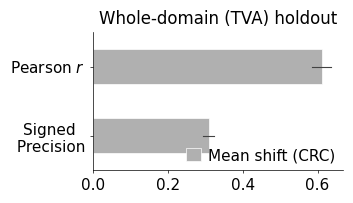

In [16]:
plot_df = pd.read_csv(f'../../results/ood_baseline_{DATASET_NAME}_DEG_{n_deg}.csv')
plot_df['model_name'] = plot_df['model_name'].map({'baseline-ood': 'Mean shift (CRC)'}).fillna(plot_df['model_name'])

mpl.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "legend.title_fontsize": 11,
    "axes.linewidth": 0.5,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.major.size": 2,
    "ytick.major.size": 2,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

metric_labels = {
    "pearson": r"Pearson $r$",
    "direction_match_k": "Signed  \n Precision",
}
metrics = list(metric_labels.keys())

df_long = plot_df.melt(id_vars="model_name", value_vars=metrics,
                       var_name="metric", value_name="value")
df_long["metric"] = df_long["metric"].map(metric_labels)

fig, ax = plt.subplots(figsize=(3.5, 2.0))
sns.barplot(
    data=df_long,
    y="metric",
    x="value",
    hue="model_name",
    palette={'Mean shift (CRC)': '#b0b0b0'},
    orient="h",
    errorbar="se",
    err_kws={"linewidth": 0.8},
    width=0.5,
    ax=ax,
    linewidth=0.5,
    edgecolor="white",
)
sns.despine(ax=ax)
ax.set_xlabel("")
ax.set_ylabel("")
ax.legend(title="", loc="lower right", frameon=False)
ax.set_title('Whole-domain (TVA) holdout')

plt.tight_layout(pad=0.5)
plt.savefig("baseline_tva_metrics.svg", dpi=300, bbox_inches="tight")
plt.show()